Current working directory: c:\Users\Sqli4\Desktop\disease-detection\epoch10\test_scripts
Dataset directory exists: True
Model path exists: True
Test images directory exists: True
🚀 Starting SC-ConvNeXt Test Script
Found 12 classes: ['aphid', 'army_worm', 'black_rust', 'brown_rust', 'common_rust', 'fusarium_head_blight', 'healthy', 'leaf_blight', 'powdery_mildew_leaf', 'spetoria', 'tan_spot', 'yellow_rust']
Using device: cpu
✅ SC-ConvNeXt model loaded successfully!
🎯 Starting visualization on test images...
Processing: 3IIC89.jpg


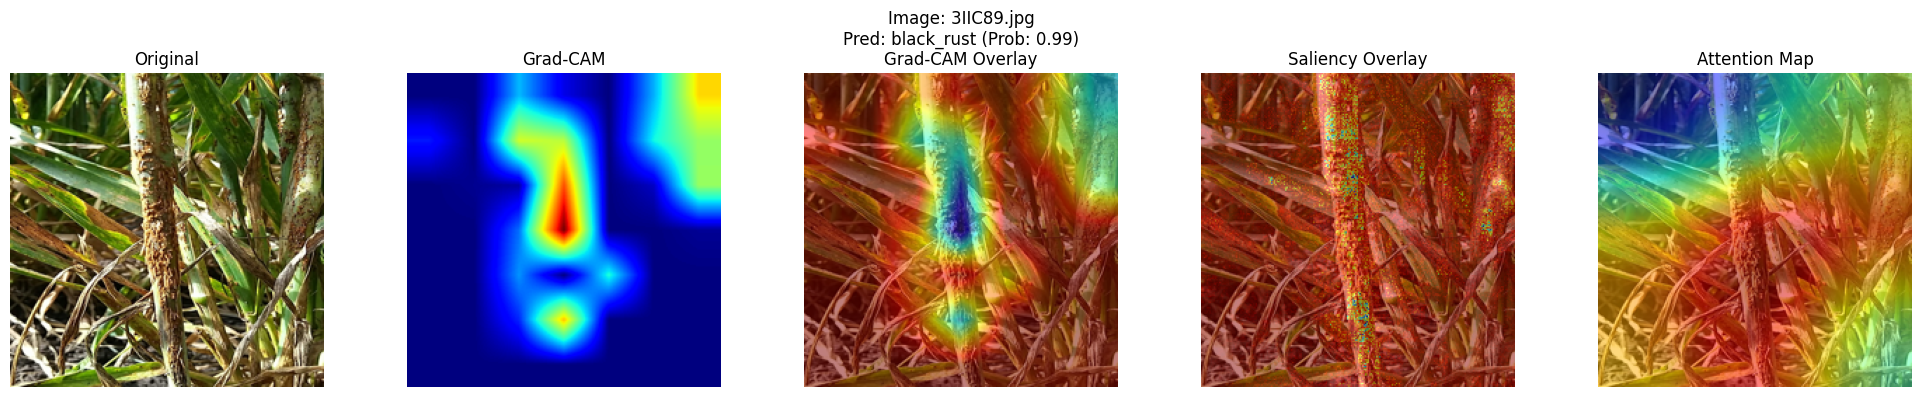

Processing: AdobeStock_515727101-1.jpeg


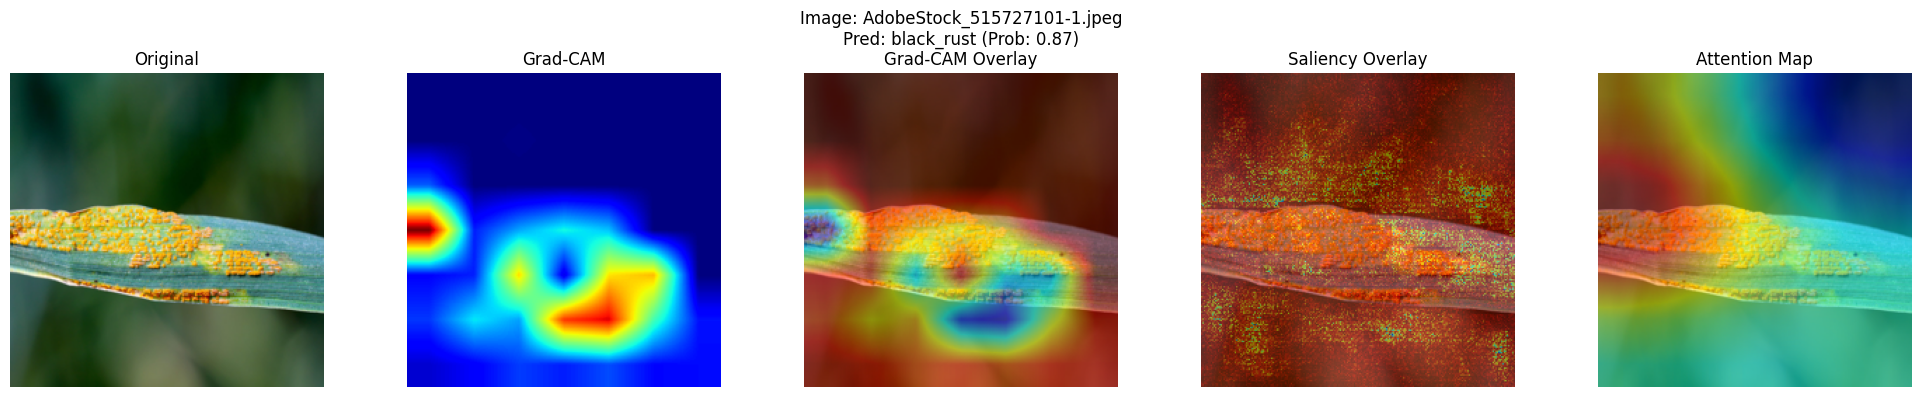

Processing: af_jun_p36-38_Fusarium_Ear_Blight_Main.jpg


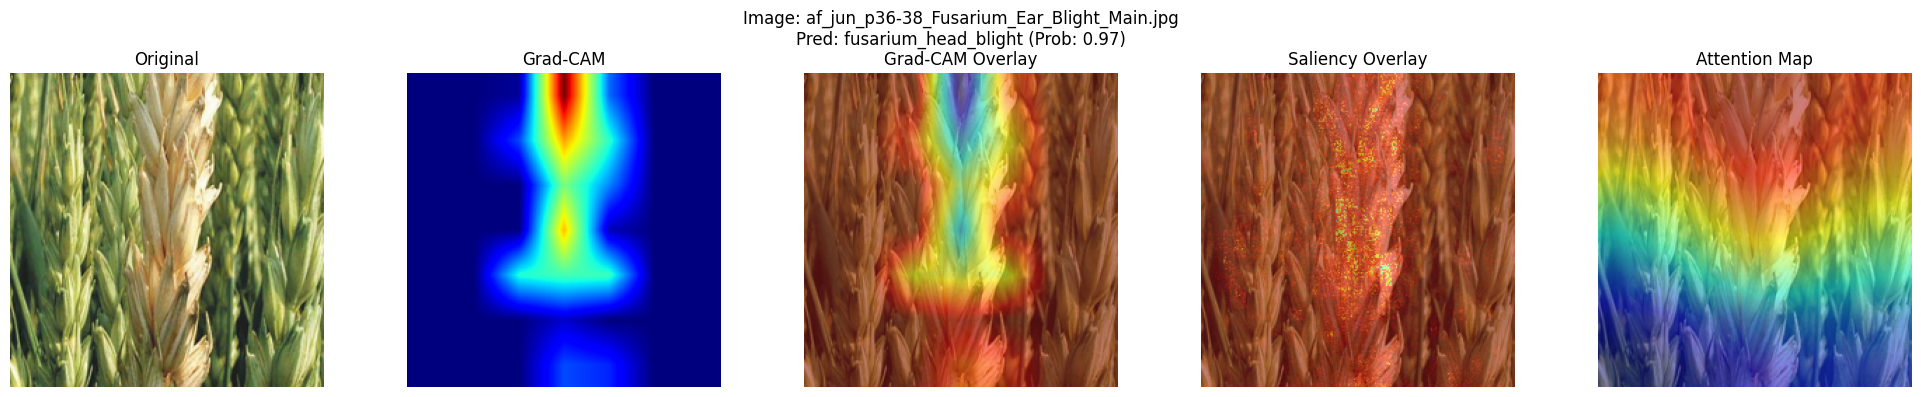

Processing: D-SG-PREC-FO.003banner.png


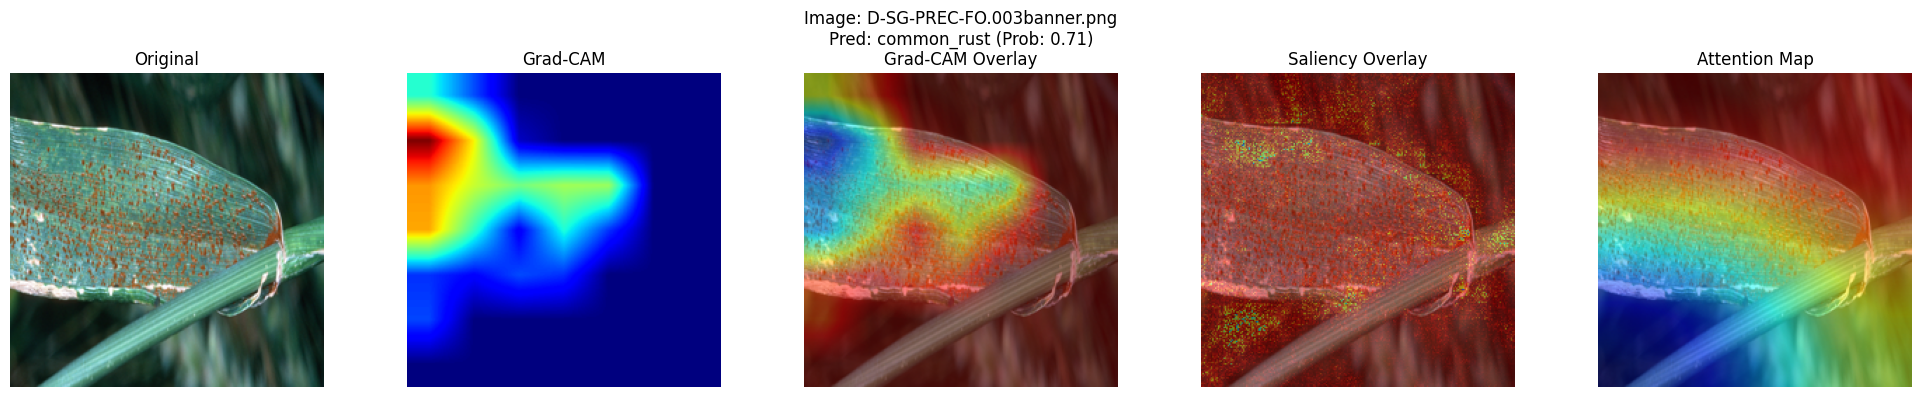

Processing: Hero Banners_Cereal Disease Hub_920x665.jpg


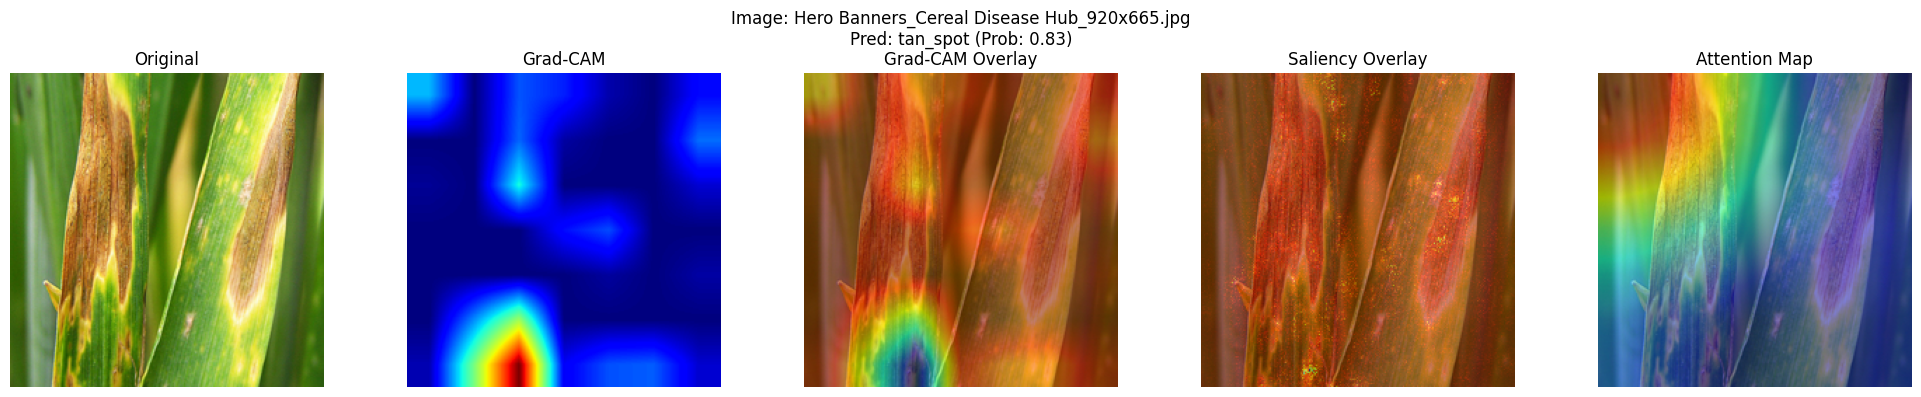

Processing: lovepik-newborn-winter-wheat-picture_501700878.jpg


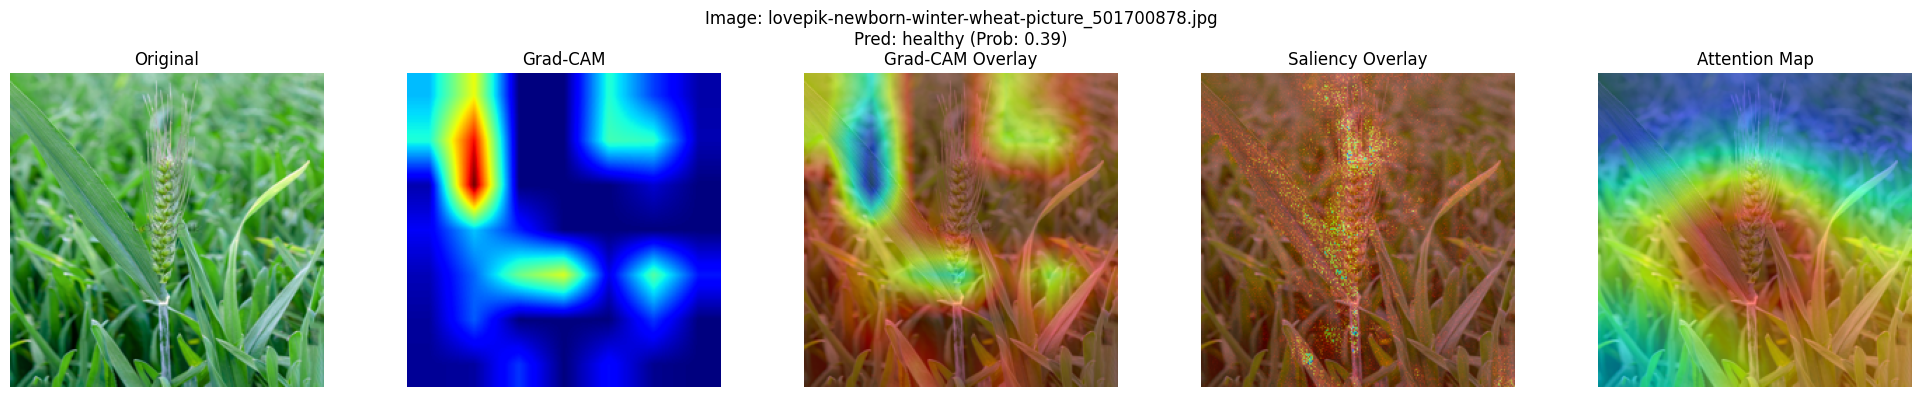

Processing: test.png


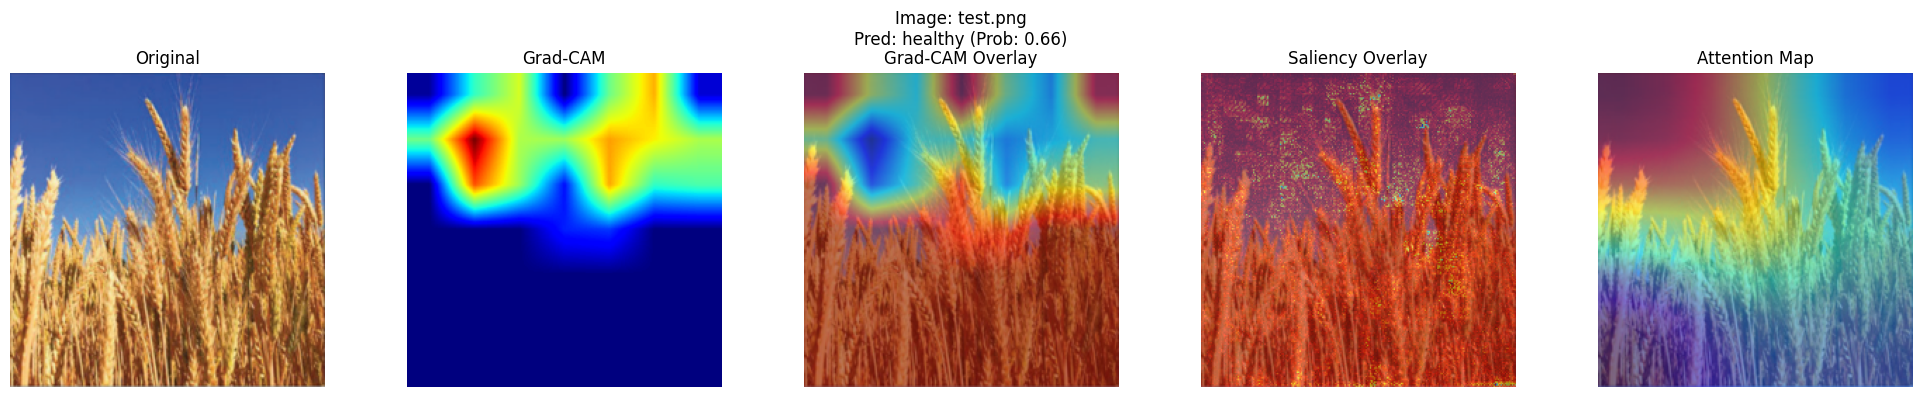

Processing: W-00261-01-wheat-streak-mosaic-virus.jpg


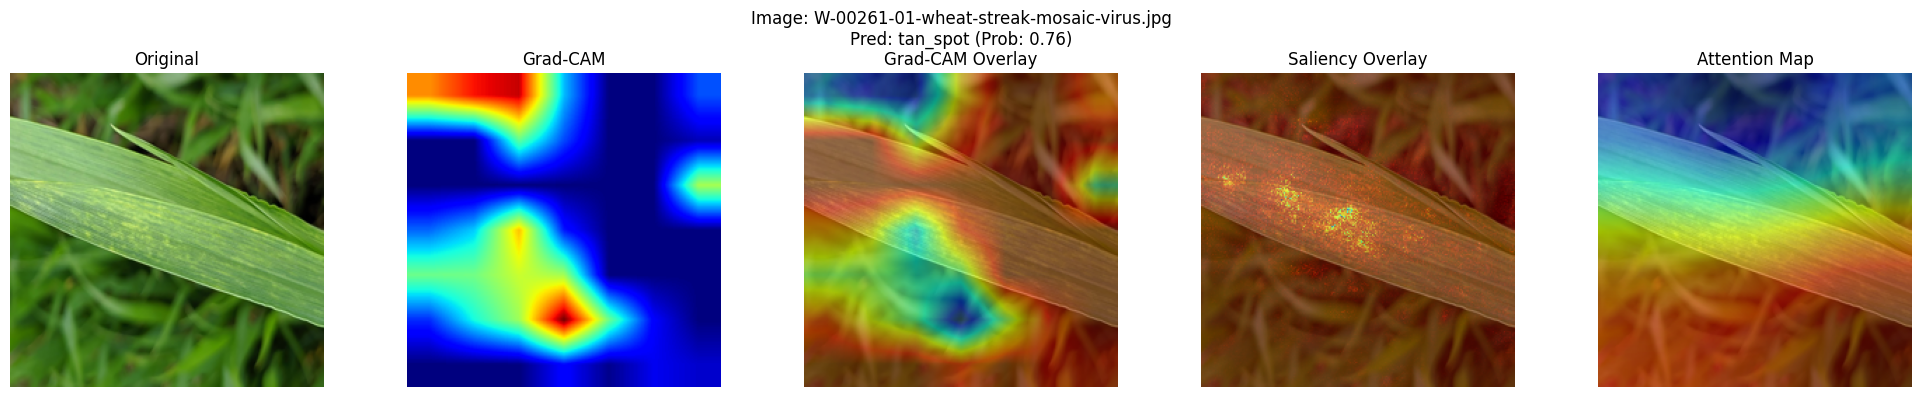

Processing: Wheat-Tunnel-green-emerged-ear-x2-close-up-1024x768.jpg


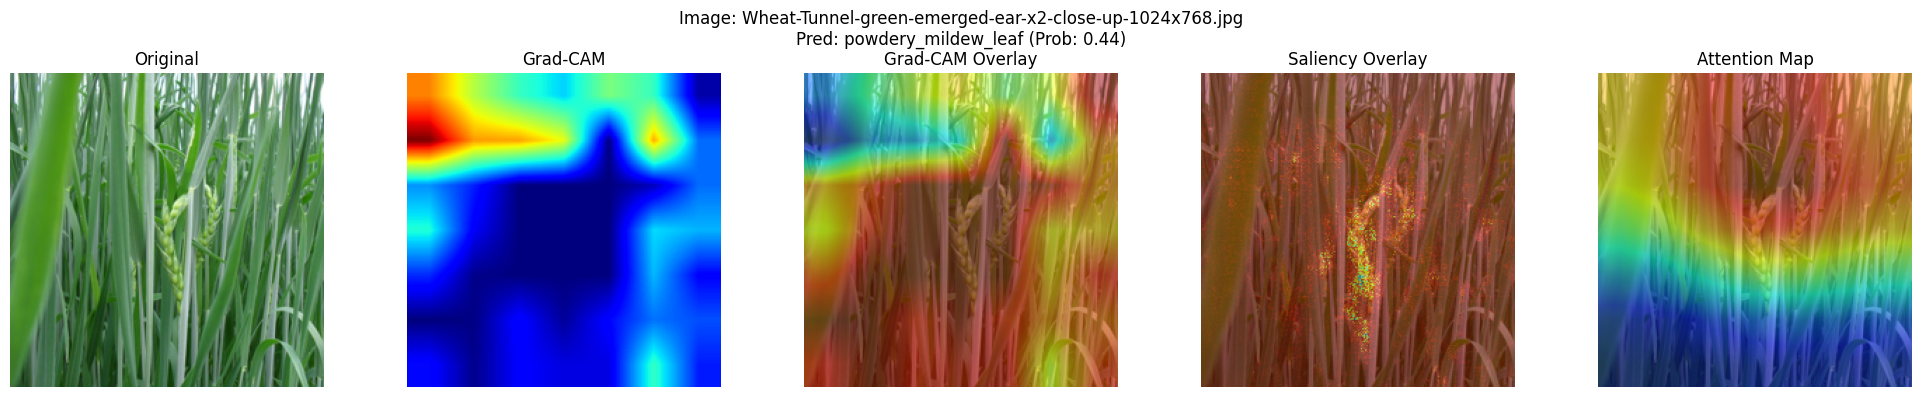

✅ Visualization complete!


In [7]:
#!/usr/bin/env python3
"""
SC-ConvNeXt Test Script - Similar to Hybrid CNN-ViT Test
Based on the training script architecture using ConvNeXt Tiny
"""

import os
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Configuration - ADJUSTED PATHS FOR epoch10/test_scripts directory
MODEL_PATH = '../../saved_models_and_data/wheat_disease_sc_convnext_model.pth'
TEST_IMAGES_DIR = '../../test_images'
DATASET_DIR = '../../dataset'
IMAGE_SIZE = (224, 224)

# Debug: Check current working directory and paths
print(f"Current working directory: {os.getcwd()}")
print(f"Dataset directory exists: {os.path.exists(DATASET_DIR)}")
print(f"Model path exists: {os.path.exists(MODEL_PATH)}")
print(f"Test images directory exists: {os.path.exists(TEST_IMAGES_DIR)}")

def get_class_labels(dataset_dir):
    """Get sorted class labels from dataset directory"""
    if not os.path.exists(dataset_dir):
        print(f"ERROR: Dataset directory '{dataset_dir}' does not exist!")
        print(f"Current working directory: {os.getcwd()}")
        print(f"Available directories: {os.listdir('.')}")
        return []
    return sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

def load_sc_convnext_model(num_classes, model_path, device):
    """
    Load SC-ConvNeXt model based on the training script architecture
    Uses ConvNeXt Tiny (768 features) as seen in the training script
    """
    class SCConvNeXt(nn.Module):
        def __init__(self, num_classes=12):
            super(SCConvNeXt, self).__init__()
            
            # Use ConvNeXt Tiny as in the training script
            from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
            self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
            
            # Replace classifier as in training script
            in_features = self.backbone.classifier[-1].in_features
            self.backbone.classifier[-1] = nn.Linear(in_features, num_classes)
            
        def forward(self, x):
            return self.backbone(x)
    
    model = SCConvNeXt(num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

class GradCAM:
    """Gradient-weighted Class Activation Mapping"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))
    
    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        loss = output[0, class_idx]
        loss.backward()
        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = gradients.mean(dim=(1, 2))
        cam = (weights[:, None, None] * activations).sum(dim=0)
        cam = torch.relu(cam)
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, IMAGE_SIZE)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam
    
    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

def compute_saliency_map(model, input_tensor, class_idx=None):
    """Compute saliency map using input gradients"""
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    model.zero_grad()
    output = model(input_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()
    loss = output[0, class_idx]
    loss.backward()
    saliency = input_tensor.grad.data.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0)
    saliency = cv2.resize(saliency, IMAGE_SIZE)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency

def compute_attention_map(model, input_tensor):
    """
    Compute attention map by visualizing feature activations from ConvNeXt features
    """
    with torch.no_grad():
        features = None
        
        def hook_fn(module, input, output):
            nonlocal features
            features = output.detach()
        
        # Use the last feature layer of ConvNeXt
        handle = model.backbone.features[-1].register_forward_hook(hook_fn)
        _ = model(input_tensor)
        handle.remove()
        
        if features is not None:
            # Compute attention map by averaging across channels
            attn_map = features.mean(dim=1).squeeze().cpu().numpy()
            
            # Apply smoothing for cleaner visualization
            attn_map = cv2.GaussianBlur(attn_map, (9, 9), 0)
            
            # Enhanced normalization
            if attn_map.max() > attn_map.min():
                attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
            else:
                attn_map = np.zeros_like(attn_map)
            
            # Resize to original image size
            attn_map = cv2.resize(attn_map, IMAGE_SIZE)
            
            return attn_map
        else:
            return np.zeros(IMAGE_SIZE)

def show_cam_on_image(img: np.ndarray, mask: np.ndarray, alpha=0.5):
    """Overlay heatmap on original image"""
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

def main():
    """Main function to run the test script"""
    print("🚀 Starting SC-ConvNeXt Test Script")
    print("=" * 50)
    
    # Get class labels
    class_labels = get_class_labels(DATASET_DIR)
    print(f"Found {len(class_labels)} classes: {class_labels}")
    
    # Setup transforms
    test_transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Setup device and model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    try:
        model = load_sc_convnext_model(len(class_labels), MODEL_PATH, device)
        print("✅ SC-ConvNeXt model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return
    
    # Set up GradCAM with the last feature layer
    target_layer = model.backbone.features[-1]
    gradcam = GradCAM(model, target_layer)
    
    print("🎯 Starting visualization on test images...")
    
    # Process each test image
    for img_name in os.listdir(TEST_IMAGES_DIR):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
            
        print(f"Processing: {img_name}")
        img_path = os.path.join(TEST_IMAGES_DIR, img_name)
        
        try:
            img_pil = Image.open(img_path).convert('RGB')
            img_tensor = test_transform(img_pil).unsqueeze(0).to(device)
            
            with torch.no_grad():
                output = model(img_tensor)
                prob = torch.softmax(output, dim=1)[0]
                pred_idx = prob.argmax().item()
                pred_label = class_labels[pred_idx]
                pred_prob = prob[pred_idx].item()
            
            # Generate visualizations
            cam = gradcam(img_tensor, class_idx=pred_idx)
            saliency = compute_saliency_map(model, img_tensor, class_idx=pred_idx)
            attn_map = compute_attention_map(model, img_tensor)
            
            # Prepare images for display
            img_np = np.array(img_pil.resize(IMAGE_SIZE)).astype(np.float32) / 255.0
            cam_img = show_cam_on_image(img_np, cam)
            sal_img = show_cam_on_image(img_np, saliency)
            attn_img = show_cam_on_image(img_np, attn_map)
            
            # Create visualization
            plt.figure(figsize=(20, 4))
            
            plt.subplot(1, 5, 1)
            plt.imshow(img_pil.resize(IMAGE_SIZE))
            plt.title('Original')
            plt.axis('off')
            
            plt.subplot(1, 5, 2)
            plt.imshow(cam, cmap='jet')
            plt.title('Grad-CAM')
            plt.axis('off')
            
            plt.subplot(1, 5, 3)
            plt.imshow(cam_img)
            plt.title('Grad-CAM Overlay')
            plt.axis('off')
            
            plt.subplot(1, 5, 4)
            plt.imshow(sal_img)
            plt.title('Saliency Overlay')
            plt.axis('off')
            
            plt.subplot(1, 5, 5)
            plt.imshow(attn_img)
            plt.title('Attention Map')
            plt.axis('off')
            
            plt.suptitle(f'Image: {img_name}\nPred: {pred_label} (Prob: {pred_prob:.2f})')
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"❌ Error processing {img_name}: {e}")
            continue
    
    gradcam.remove_hooks()
    print("✅ Visualization complete!")

if __name__ == "__main__":
    main()
